## Librerias

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Fix for Python 3.10+ compatibility with arelle - collections ABC migration
import collections
from collections.abc import MutableSet, MutableMapping, MutableSequence, Iterable, Mapping, Sequence
collections.MutableSet = MutableSet
collections.MutableMapping = MutableMapping
collections.MutableSequence = MutableSequence
collections.Iterable = Iterable
collections.Mapping = Mapping
collections.Sequence = Sequence

# Fix for Python 3.12 compatibility - imp module was removed
import sys
import importlib.util
sys.modules['imp'] = importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arelle import Cntlr
import os

# Nutresa KMV

In [3]:
# Lectura de datos XBRL - Nutresa Superfinanciera Liabilities

XBRL_PATH_NUTRESA = "Informes Nutresa"

FINANCIAL_STATEMENTS_NUTRESA = {
    "NUTRESA-20201231": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01", "2020-10-01"],
    "NUTRESA-20211231": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01", "2021-10-01"],
    "NUTRESA-20221231": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01", "2022-10-01"],
    "NUTRESA-20231231": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01", "2023-10-01"],
    "NUTRESA-20240331": ["0053714776_0066_000032_0000_000000_000000_C-I_2024-03-31.xbrl", "2024-04-01", "2024-01-01"],
    "NUTRESA-20240630": ["0053797199_0066_000032_0000_000000_000000_C-I_2024-06-30.xbrl", "2024-07-01", "2024-04-01"],
    "NUTRESA-20240930": ["0053887565_0066_000032_0000_000000_000000_C-I_2024-09-30.xbrl", "2024-10-01", "2024-07-01"],
    "NUTRESA-20241231": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01", "2024-10-01"],
    "NUTRESA-20250331": ["0054071583_0066_000032_0000_000000_000000_C-I_2025-03-31.xbrl", "2025-04-01", "2025-01-01"],
    "NUTRESA-20250630": ["0054141770_0066_000032_0000_000000_000000_C-I_2025-06-30.xbrl", "2025-07-01", "2025-04-01"],
    "NUTRESA-20250930": ["0054231647_0066_000032_0000_000000_000000_C-I_2025-09-30.xbrl", "2025-10-01", "2025-07-01"],
    "NUTRESA-20251231": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01", "2025-10-01"],
}

list_of_rows_nutresa = []

# Iterate through the dictionary - extract Equity, ProfitLoss, and Liabilities
for key in FINANCIAL_STATEMENTS_NUTRESA:
    
    COMPANY_FS = FINANCIAL_STATEMENTS_NUTRESA[key][0]
    XBRL_FILE = os.path.join(XBRL_PATH_NUTRESA, COMPANY_FS)
    
    # Import XBRL file
    xbrl = Cntlr.Cntlr().modelManager.load(XBRL_FILE)   
    
    # Extract all numeric facts into simple tuples
    facts_list = []
    for fact in xbrl.facts:
        if fact.isNumeric:
            facts_list.append((
                str(fact.concept.qname),
                fact.value,
                fact.context.startDatetime,
                fact.context.endDatetime
            ))
    
    # Create dataframe and assign column names directly
    if len(facts_list) > 0:
        factData = pd.DataFrame(facts_list, columns=['name', 'value', 'startDatetime', 'endDatetime'])
        
        # Convert value to numeric
        factData['value'] = pd.to_numeric(factData['value'], errors='coerce')
        
        period_end = pd.to_datetime(FINANCIAL_STATEMENTS_NUTRESA[key][1])
        period_start = pd.to_datetime(FINANCIAL_STATEMENTS_NUTRESA[key][2])
        
        # Extract EQUITY (instant period)
        Equity = factData[(factData['name']=="ifrs:Equity") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Extract PROFITLOSS / NET INCOME (duration period)
        CurrentLiabilities = factData[(factData['name']=="ifrs:CurrentLiabilities") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Extract LIABILITIES (instant period)
        Liabilities = factData[(factData['name']=="ifrs:Liabilities") & (factData['endDatetime']==period_end)]['value'].values[0]

        # Extract LIABILITIES (instant period)
        Shares = factData[(factData['name']=="ifrs:NumberOfSharesOutstanding") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Create row dict and append to list
        row_dict = {
            'Date': FINANCIAL_STATEMENTS_NUTRESA[key][1],
            'Equity': Equity,
            'Liabilities': Liabilities,
            'CurrentLiabilities': CurrentLiabilities,
            'SharesOutstanding': Shares
        }
        list_of_rows_nutresa.append(row_dict)
        print(f"✓ {key} extracted - Equity: {Equity:.0f}, CurrentLiabilities: {CurrentLiabilities:.0f}, Liabilities: {Liabilities:.0f},shares: {Shares:.0f}")

# Create final dataframe from list of dicts
data_summary_df_nutresa = pd.DataFrame(list_of_rows_nutresa)

✓ NUTRESA-20201231 extracted - Equity: 8257141744, CurrentLiabilities: 2440661120, Liabilities: 7280740775,shares: 460123458
✓ NUTRESA-20211231 extracted - Equity: 9042111934, CurrentLiabilities: 2628037175, Liabilities: 7914370766,shares: 457755869
✓ NUTRESA-20221231 extracted - Equity: 10804696453, CurrentLiabilities: 3808715417, Liabilities: 9952691427,shares: 457755869
✓ NUTRESA-20231231 extracted - Equity: 6444251335, CurrentLiabilities: 3703271713, Liabilities: 9244578686,shares: 457755869
✓ NUTRESA-20240331 extracted - Equity: 6517738701, CurrentLiabilities: 3319458865, Liabilities: 8859939077,shares: 0
✓ NUTRESA-20240630 extracted - Equity: 7031866908, CurrentLiabilities: 3391174330, Liabilities: 9294203371,shares: 0
✓ NUTRESA-20240930 extracted - Equity: 6849714676, CurrentLiabilities: 3647421268, Liabilities: 9938925195,shares: 0
✓ NUTRESA-20241231 extracted - Equity: 7118852385, CurrentLiabilities: 3701406666, Liabilities: 9823609331,shares: 457755869
✓ NUTRESA-20250331 extr

In [4]:
# Cargar precios históricos de Nutresa

precios_file = "Prices.xlsx"

# Read Nutresa prices
df_precios_nutresa = pd.read_excel(precios_file, sheet_name='Prices', engine='openpyxl')
df_precios_nutresa['Fecha'] = pd.to_datetime(df_precios_nutresa['Fecha'])

Nutresa = df_precios_nutresa[["Fecha","NUTRESA"]].copy()
Nutresa['return'] = Nutresa['NUTRESA']/Nutresa['NUTRESA'].shift(1) - 1
Nutresa['volatility'] = Nutresa['return'].rolling(window=252).std()*252**0.5
Nutresa.set_index('Fecha', inplace=True)

print("Precios de Nutresa cargados:")
print(Nutresa.tail())

Precios de Nutresa cargados:
            NUTRESA    return  volatility
Fecha                                    
2026-01-29   304500  0.000000    0.471750
2026-01-30   304500  0.000000    0.471750
2026-02-02   304500  0.000000    0.464005
2026-02-03   295000 -0.031199    0.458708
2026-02-04   319000  0.081356    0.461891


In [5]:
# Unificación de datos - Datos financieros + Precio coincidente

# Preparar datos
if 'Date' not in data_summary_df_nutresa.columns:
    data_summary_df_nutresa = data_summary_df_nutresa.reset_index()

data_summary_df_nutresa['Date'] = pd.to_datetime(data_summary_df_nutresa['Date'])
data_summary_df_nutresa.set_index('Date', inplace=True)

# Merge simple por fecha con tolerancia de 5 días hacia atrás
KMV_DATA_NUTRESA = pd.merge_asof(data_summary_df_nutresa, Nutresa, 
                                  left_index=True, 
                                  right_index=True, 
                                  tolerance=pd.Timedelta('5D'),
                                  direction='backward')

# Restaurar Date como columna y renombrar NUTRESA a Price
KMV_DATA_NUTRESA['Date'] = KMV_DATA_NUTRESA.index
KMV_DATA_NUTRESA = KMV_DATA_NUTRESA.reset_index(drop=True)
KMV_DATA_NUTRESA = KMV_DATA_NUTRESA.rename(columns={'NUTRESA': 'Price'})

print("Datos merged Nutresa:")
print(KMV_DATA_NUTRESA[['Date', 'Equity', 'Liabilities', "CurrentLiabilities", 'Price', 'volatility']])

Datos merged Nutresa:
         Date        Equity   Liabilities  CurrentLiabilities   Price  \
0  2021-01-01  8.257142e+09  7.280741e+09        2.440661e+09   24000   
1  2022-01-01  9.042112e+09  7.914371e+09        2.628037e+09   28640   
2  2023-01-01  1.080470e+10  9.952691e+09        3.808715e+09   44500   
3  2024-01-01  6.444251e+09  9.244579e+09        3.703272e+09   45000   
4  2024-04-01  6.517739e+09  8.859939e+09        3.319459e+09   46800   
5  2024-07-01  7.031867e+09  9.294203e+09        3.391174e+09   51800   
6  2024-10-01  6.849715e+09  9.938925e+09        3.647421e+09   69740   
7  2025-01-01  7.118852e+09  9.823609e+09        3.701407e+09   79000   
8  2025-04-01  7.209828e+09  1.835279e+10        1.164962e+10  123280   
9  2025-07-01  7.129058e+09  1.902920e+10        4.150212e+09  130000   
10 2025-10-01  6.625515e+09  2.066279e+10        4.374328e+09  174000   
11 2026-01-01  5.416712e+09  2.200261e+10        4.473368e+09  282000   

    volatility  
0     0.298

In [6]:
# Preparación de datos KMV - Nutresa

# Número de acciones en circulación de Nutresa
shares_outstanding_nutresa = 457755869 #Usamos este valor fijo porque en algunos xblr no viene el número de acciones
# Preparar datos para el iterador KMV
KMV_DATA_NUTRESA['Market_Cap'] = KMV_DATA_NUTRESA['Price'] * shares_outstanding_nutresa

KMV_DATA_NUTRESA['Liabilities_NonCurrent'] = KMV_DATA_NUTRESA['Liabilities'] - KMV_DATA_NUTRESA['CurrentLiabilities'] 
# Default Point = Pasivos Corrientes + 0.5 * Pasivos No Corrientes
KMV_DATA_NUTRESA['Default_Point'] = KMV_DATA_NUTRESA['CurrentLiabilities'] + 0.5 * KMV_DATA_NUTRESA['Liabilities_NonCurrent']

print("Datos preparados para KMV - Nutresa:")
print(KMV_DATA_NUTRESA[['Date', 'Market_Cap', 'Liabilities', 'Default_Point', 'volatility']])

Datos preparados para KMV - Nutresa:
         Date       Market_Cap   Liabilities  Default_Point  volatility
0  2021-01-01   10986140856000  7.280741e+09   4.860701e+09    0.298313
1  2022-01-01   13110128088160  7.914371e+09   5.271204e+09    0.320562
2  2023-01-01   20370136170500  9.952691e+09   6.880703e+09    0.872758
3  2024-01-01   20599014105000  9.244579e+09   6.473925e+09    0.320993
4  2024-04-01   21422974669200  8.859939e+09   6.089699e+09    0.228823
5  2024-07-01   23711754014200  9.294203e+09   6.342689e+09    0.458180
6  2024-10-01   31923894304060  9.938925e+09   6.793173e+09    0.469025
7  2025-01-01   36162713651000  9.823609e+09   6.762508e+09    0.488327
8  2025-04-01   56432143530320  1.835279e+10   1.500121e+10    0.536659
9  2025-07-01   59508262970000  1.902920e+10   1.158971e+10    0.373053
10 2025-10-01   79649521206000  2.066279e+10   1.251856e+10    0.371854
11 2026-01-01  129087155058000  2.200261e+10   1.323799e+10    0.484315


In [7]:

# Importar funciones necesarias para el cálculo KMV
from scipy.stats import norm, t as t_dist
from scipy.optimize import root

# Algoritmo KMV - Iteración Merton Model

kmv_results_nutresa = pd.DataFrame()

for i in range(len(KMV_DATA_NUTRESA)):
    
    # Datos del período
    equity_vol = KMV_DATA_NUTRESA['volatility'].iloc[i]
    market_cap = KMV_DATA_NUTRESA['Market_Cap'].iloc[i]
    liabilities_current = KMV_DATA_NUTRESA['CurrentLiabilities'].iloc[i]
    liabilities_noncurrent = KMV_DATA_NUTRESA['Liabilities_NonCurrent'].iloc[i]
    date = KMV_DATA_NUTRESA['Date'].iloc[i]
    

    # Inicialización
    initial_assets = market_cap + liabilities_current + liabilities_noncurrent
    assets = initial_assets
    liabilities = liabilities_current + liabilities_noncurrent
    dp = liabilities_current + 0.5 * liabilities_noncurrent  # Default Point
    initial_asset_vol = equity_vol
    asset_vol = initial_asset_vol
    equity = market_cap
    
    # Parámetros del modelo
    r = 0.05  # Risk-free rate
    T = 1     # Time horizon (1 year)
    epsilon = 1  # Inicializar convergencia
    iterations = 0
    max_iterations = 1000
    
    # Ecuaciones Merton Model
    def function1(x):
        d1 = (np.log(x/dp) + (r + 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
        d2 = (np.log(x/dp) + (r - 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
        return x - (market_cap + np.exp(-r*T)*dp*norm.cdf(d2))
    
    def function2(x):
        d1 = (np.log(assets/dp) + (r + 0.5*x**2)*T) / (x*T**0.5)
        return equity_vol - norm.cdf(d1) * (assets/market_cap) * x
    
    # Iteración hasta convergencia
    while epsilon > 0.00001 and iterations < max_iterations:
        # Resolver para asset_vol
        try:
            sol2 = root(function2, asset_vol, method='hybr')
            asset_vol_new = sol2.x[0]
        except:
            asset_vol_new = asset_vol
        
        # Resolver para assets
        try:
            sol1 = root(function1, assets, method='hybr')
            assets_new = sol1.x[0]
        except:
            assets_new = assets
        
        epsilon = abs(asset_vol_new - asset_vol)
        asset_vol = asset_vol_new
        assets = assets_new
        iterations += 1
    
    # Calcular d1 y d2 finales
    d1 = (np.log(assets/dp) + (r + 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
    d2 = (np.log(assets/dp) + (r - 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
    
    # Probabilidad de default usando t-student
    default_prob = t_dist.cdf(-d2, 5)  # t-student con 5 grados de libertad
    
    # Almacenar resultados
    result_row = {
        'Date': date,
        'Assets': assets,
        'Liabilities': liabilities,
        'Liabilities_Current': liabilities_current,
        'Liabilities_NonCurrent': liabilities_noncurrent,
        'Default_Point': dp,
        'Market_Cap': market_cap,
        'Equity_Vol': equity_vol,
        'Asset_Vol': asset_vol,
        'd1': d1,
        'd2': d2,
        'Default_Prob': default_prob,
        'Distance_to_Default': d2,
        'Iterations': iterations
    }
    
    kmv_results_nutresa = pd.concat([kmv_results_nutresa, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  ✓ Asset Vol: {asset_vol:.4f} | d2: {d2:.4f} | Default Prob: {default_prob*100:.4f}%")

print("\n" + "="*80)
print("✓ ITERACIÓN COMPLETADA - NUTRESA")
print("="*80)
print(f"\nResultados: {len(kmv_results_nutresa)} períodos calculados")
print("\nPrimeras filas:")
print(kmv_results_nutresa[['Date', 'Assets', 'Asset_Vol', 'd2', 'Default_Prob']].head())

  ✓ Asset Vol: 0.2982 | d2: 25.9205 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.3204 | d2: 24.3975 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.8725 | d2: 8.7828 | Default Prob: 0.0159%
  ✓ Asset Vol: 0.3209 | d2: 25.1297 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.2288 | d2: 35.8004 | Default Prob: 0.0000%
  ✓ Asset Vol: 0.4581 | d2: 17.8398 | Default Prob: 0.0005%
  ✓ Asset Vol: 0.4689 | d2: 17.9034 | Default Prob: 0.0005%
  ✓ Asset Vol: 0.4882 | d2: 17.4410 | Default Prob: 0.0006%
  ✓ Asset Vol: 0.5365 | d2: 15.1699 | Default Prob: 0.0011%
  ✓ Asset Vol: 0.3730 | d2: 22.8546 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.3718 | d2: 23.5052 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.4843 | d2: 18.8284 | Default Prob: 0.0004%

✓ ITERACIÓN COMPLETADA - NUTRESA

Resultados: 12 períodos calculados

Primeras filas:
        Date        Assets  Asset_Vol         d2  Default_Prob
0 2021-01-01  1.099076e+13   0.298187  25.920539  7.982757e-07
1 2022-01-01  1.311514e+13   0.320439  24.397515  1.078351e-06
2 202

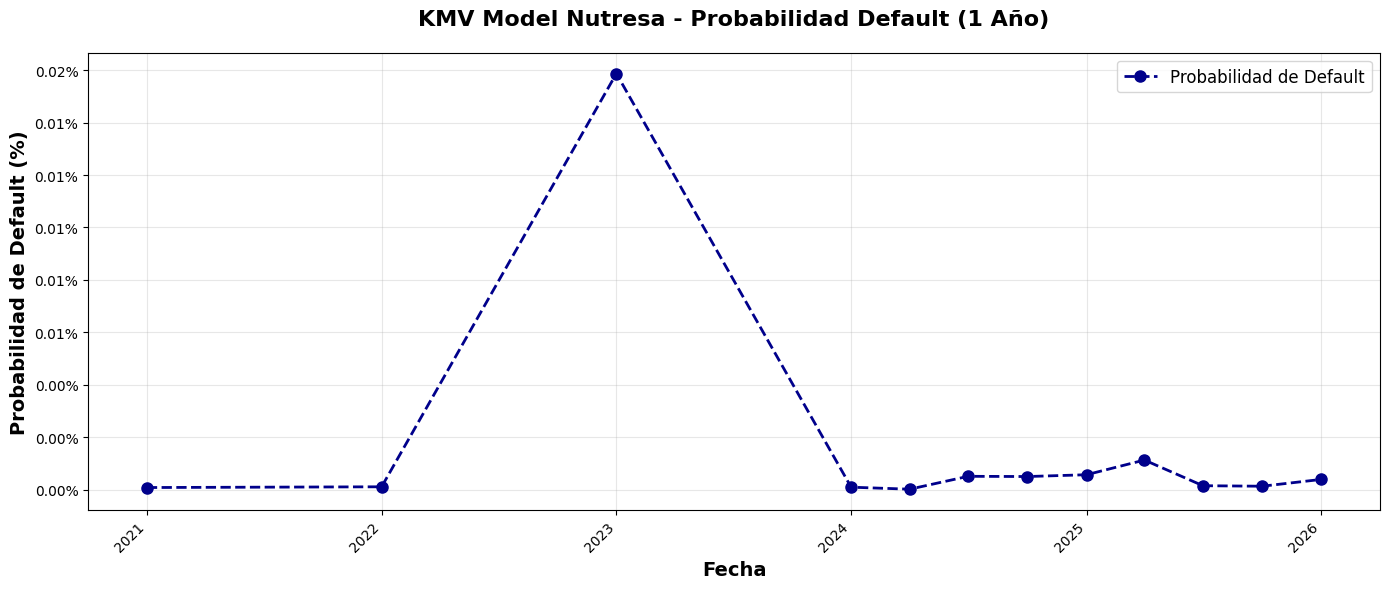

In [8]:
## Visualización de Resultados - Nutresa

# Gráfico de Probabilidad de Default
fig, ax = plt.subplots(figsize=(14, 6))

kmv_results_nutresa_sorted = kmv_results_nutresa.sort_values('Date')

ax.plot(kmv_results_nutresa_sorted['Date'], 
        kmv_results_nutresa_sorted['Default_Prob']*100, 
        marker='o', 
        linestyle='dashed', 
        color='darkblue', 
        label='Probabilidad de Default', 
        markersize=8,
        linewidth=2)

ax.set_xlabel('Fecha', fontsize=14, fontweight='bold')
ax.set_ylabel('Probabilidad de Default (%)', fontsize=14, fontweight='bold')
ax.set_title('KMV Model Nutresa - Probabilidad Default (1 Año)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}%'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Nutresa:Financial Analysis

## Deuda / EBITDA

In [9]:
# PASO 1: Extraer SOLO ifrs:FinancialLiabilities de todos los años

print("PASO 1: Extrayendo ifrs:FinancialLiabilities")
print("="*100)

financial_liabilities_data = {}

years_to_extract = {
    "2020": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01"],
    "2021": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01"],
    "2022": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01"],
    "2023": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01"],
    "2024": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01"],
    "2025": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01"],
}

for year, (xbrl_filename, period_end_str) in years_to_extract.items():
    xbrl_file = os.path.join(XBRL_PATH_NUTRESA, xbrl_filename)
    period_end = pd.to_datetime(period_end_str)
    
    xbrl = Cntlr.Cntlr().modelManager.load(xbrl_file)
    
    # Buscar ifrs:FinancialLiabilities
    for fact in xbrl.facts:
        concepto = str(fact.concept.qname)
        fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
        
        if concepto == 'ifrs:FinancialLiabilities' and fecha_fin == period_end:
            valor = float(fact.value) if fact.value else 0
            financial_liabilities_data[year] = valor
            print(f"✓ {year}: ifrs:FinancialLiabilities = ${valor:>20,.0f}")
            break

print("\n" + "="*100)
print(f"Resultado: Se extrajeron {len(financial_liabilities_data)} años")
print("="*100)
for year, valor in sorted(financial_liabilities_data.items()):
    print(f"  {year}: ${valor:>20,.0f}")

PASO 1: Extrayendo ifrs:FinancialLiabilities
✓ 2020: ifrs:FinancialLiabilities = $       3,352,373,952
✓ 2021: ifrs:FinancialLiabilities = $       3,341,489,438
✓ 2022: ifrs:FinancialLiabilities = $       4,371,128,576
✓ 2023: ifrs:FinancialLiabilities = $       4,103,957,340
✓ 2024: ifrs:FinancialLiabilities = $       4,404,151,490
✓ 2025: ifrs:FinancialLiabilities = $      16,311,565,737

Resultado: Se extrajeron 6 años
  2020: $       3,352,373,952
  2021: $       3,341,489,438
  2022: $       4,371,128,576
  2023: $       4,103,957,340
  2024: $       4,404,151,490
  2025: $      16,311,565,737


In [10]:

# PASO 2: Extracción de ifrs:ProfitLossFromOperatingActivities (Filtrar por período completo)

print("PASO 2: Extrayendo ifrs:ProfitLossFromOperatingActivities (Período Completo)")
print("=" * 100)

operating_profit_data = {}

years_to_extract = {
    "2020": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01"],
    "2021": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01"],
    "2022": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01"],
    "2023": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01"],
    "2024": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01"],
    "2025": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01"],
}

for year, (xbrl_filename, period_end_str) in years_to_extract.items():
    xbrl_file = os.path.join(XBRL_PATH_NUTRESA, xbrl_filename)
    period_end = pd.to_datetime(period_end_str)
    period_start = pd.to_datetime(f"{int(year)}-01-01")  # 1 de enero del mismo año
    
    xbrl = Cntlr.Cntlr().modelManager.load(xbrl_file)
    
    # Buscar ifrs:ProfitLossFromOperatingActivities (Duration fact, período completo)
    encontrado = False
    for fact in xbrl.facts:
        concepto = str(fact.concept.qname)
        
        if concepto == 'ifrs:ProfitLossFromOperatingActivities':
            fecha_inicio = fact.context.startDatetime if hasattr(fact.context, 'startDatetime') else None
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            
            # Buscar valor con período COMPLETO del año
            if fecha_inicio == period_start and fecha_fin == period_end:
                valor = float(fact.value) if fact.value else 0
                operating_profit_data[year] = valor
                context_id = fact.context.id
                print(f"✓ {year}: ifrs:ProfitLossFromOperatingActivities = ${valor:>20,.0f} ({context_id})")
                encontrado = True
                break
    
    if not encontrado:
        print(f"⚠ {year}: No se encontró con período completo (Ene 1 - Ene 1)")
        operating_profit_data[year] = 0

print("\n" + "=" * 100)
print(f"Resultado: Se extrajeron {len([v for v in operating_profit_data.values() if v != 0])} años con valores")
print("=" * 100)
for year, valor in sorted(operating_profit_data.items()):
    print(f"  {year}: ${valor:>20,.0f}")


PASO 2: Extrayendo ifrs:ProfitLossFromOperatingActivities (Período Completo)
✓ 2020: ifrs:ProfitLossFromOperatingActivities = $       1,019,587,589 (_ctx4)
✓ 2021: ifrs:ProfitLossFromOperatingActivities = $       1,105,297,341 (_ctx4)
✓ 2022: ifrs:ProfitLossFromOperatingActivities = $       1,506,499,705 (_ctx4)
✓ 2023: ifrs:ProfitLossFromOperatingActivities = $       1,728,156,960 (_ctx4)
✓ 2024: ifrs:ProfitLossFromOperatingActivities = $       1,840,995,954 (_ctx4)
✓ 2025: ifrs:ProfitLossFromOperatingActivities = $       2,403,358,153 (_ctx4)

Resultado: Se extrajeron 6 años con valores
  2020: $       1,019,587,589
  2021: $       1,105,297,341
  2022: $       1,506,499,705
  2023: $       1,728,156,960
  2024: $       1,840,995,954
  2025: $       2,403,358,153


In [11]:

# PASO 3: Extracción de ifrs:DepreciationAndAmortisationExpense (Mayor valor para período)

print("PASO 3: Extrayendo ifrs:DepreciationAndAmortisationExpense")
print("=" * 100)

depreciation_data = {}

years_to_extract = {
    "2020": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01"],
    "2021": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01"],
    "2022": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01"],
    "2023": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01"],
    "2024": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01"],
    "2025": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01"],
}

for year, (xbrl_filename, period_end_str) in years_to_extract.items():
    xbrl_file = os.path.join(XBRL_PATH_NUTRESA, xbrl_filename)
    period_end = pd.to_datetime(period_end_str)
    period_start = pd.to_datetime(f"{int(year)}-01-01")
    
    xbrl = Cntlr.Cntlr().modelManager.load(xbrl_file)
    
    # Recopilar TODOS los valores de DepreciationAndAmortisationExpense para este período
    values_for_period = []
    for fact in xbrl.facts:
        concepto = str(fact.concept.qname)
        
        if concepto == 'ifrs:DepreciationAndAmortisationExpense':
            fecha_inicio = fact.context.startDatetime if hasattr(fact.context, 'startDatetime') else None
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            
            # Si coincide el período
            if fecha_inicio == period_start and fecha_fin == period_end:
                valor = float(fact.value) if fact.value else 0
                context_id = fact.context.id
                values_for_period.append((valor, context_id))
    
    # Seleccionar el VALOR MÁXIMO (probablemente consolidado)
    if values_for_period:
        max_valor, max_context = max(values_for_period, key=lambda x: x[0])
        depreciation_data[year] = max_valor
        print(f"✓ {year}: ifrs:DepreciationAndAmortisationExpense = ${max_valor:>20,.0f} ({max_context})")
    else:
        print(f"⚠ {year}: No se encontró para período completo")
        depreciation_data[year] = 0

print("\n" + "=" * 100)
print(f"Resultado: Se extrajeron {len([v for v in depreciation_data.values() if v != 0])} años con valores")
print("=" * 100)
for year, valor in sorted(depreciation_data.items()):
    print(f"  {year}: ${valor:>20,.0f}")


PASO 3: Extrayendo ifrs:DepreciationAndAmortisationExpense
✓ 2020: ifrs:DepreciationAndAmortisationExpense = $         421,384,706 (_ctx2794)
✓ 2021: ifrs:DepreciationAndAmortisationExpense = $         420,654,336 (_ctx2794)
✓ 2022: ifrs:DepreciationAndAmortisationExpense = $         467,689,991 (_ctx2794)
✓ 2023: ifrs:DepreciationAndAmortisationExpense = $         485,025,631 (_ctx2794)
✓ 2024: ifrs:DepreciationAndAmortisationExpense = $         522,839,461 (_ctx2794)
✓ 2025: ifrs:DepreciationAndAmortisationExpense = $         506,480,719 (_ctx2794)

Resultado: Se extrajeron 6 años con valores
  2020: $         421,384,706
  2021: $         420,654,336
  2022: $         467,689,991
  2023: $         485,025,631
  2024: $         522,839,461
  2025: $         506,480,719


In [12]:

# PASO 4: Cálculo de EBITDA (Operating Profit + Depreciation)

print("PASO 4: Calculando EBITDA = Operating Profit + Depreciation")
print("=" * 100)

ebitda_data = {}

for year in sorted(financial_liabilities_data.keys()):
    op_profit = operating_profit_data.get(year, 0)
    depreciation = depreciation_data.get(year, 0)
    ebitda = op_profit + depreciation
    
    ebitda_data[year] = ebitda
    
    print(f"{year}:")
    print(f"  Operating Profit:    ${op_profit:>20,.0f}")
    print(f"  Depreciation:        ${depreciation:>20,.0f}")
    print(f"  EBITDA:              ${ebitda:>20,.0f}")
    print()

print("=" * 100)
print("Resumen de EBITDA por año:")
print("=" * 100)
for year in sorted(ebitda_data.keys()):
    ebitda = ebitda_data[year]
    print(f"  {year}: ${ebitda:>20,.0f}")


PASO 4: Calculando EBITDA = Operating Profit + Depreciation
2020:
  Operating Profit:    $       1,019,587,589
  Depreciation:        $         421,384,706
  EBITDA:              $       1,440,972,295

2021:
  Operating Profit:    $       1,105,297,341
  Depreciation:        $         420,654,336
  EBITDA:              $       1,525,951,677

2022:
  Operating Profit:    $       1,506,499,705
  Depreciation:        $         467,689,991
  EBITDA:              $       1,974,189,696

2023:
  Operating Profit:    $       1,728,156,960
  Depreciation:        $         485,025,631
  EBITDA:              $       2,213,182,591

2024:
  Operating Profit:    $       1,840,995,954
  Depreciation:        $         522,839,461
  EBITDA:              $       2,363,835,415

2025:
  Operating Profit:    $       2,403,358,153
  Depreciation:        $         506,480,719
  EBITDA:              $       2,909,838,872

Resumen de EBITDA por año:
  2020: $       1,440,972,295
  2021: $       1,525,951,677
 

In [13]:

# PASO 5: Cálculo de Deuda/EBITDA Ratio y Visualización

print("PASO 5: Calculando Deuda/EBITDA Ratio")
print("=" * 100)

ratio_data = {}

for year in sorted(financial_liabilities_data.keys()):
    debt_value = financial_liabilities_data.get(year, 0)
    ebitda_value = ebitda_data.get(year, 0)
    
    if ebitda_value != 0:
        ratio = debt_value / ebitda_value
    else:
        ratio = 0
    
    ratio_data[year] = ratio
    
    print(f"{year}: Deuda/EBITDA = ${debt_value:>15,.0f} / ${ebitda_value:>15,.0f} = {ratio:.2f}x")

print("\n" + "=" * 100)
print("Resumen del Ratio Deuda/EBITDA:")
print("=" * 100)
for year in sorted(ratio_data.keys()):
    ratio = ratio_data[year]
    debt_billions = financial_liabilities_data[year] / 1e9
    print(f"  {year}: {ratio:.2f}x  (Deuda: ${debt_billions:.2f}B COP)")

# Crear DataFrame para visualización
years_list = sorted(financial_liabilities_data.keys())
debt_billions = [financial_liabilities_data[year] / 1e9 for year in years_list]
ratios = [ratio_data[year] for year in years_list]

df_debt_ebitda = pd.DataFrame({
    'Año': years_list,
    'Deuda_Billions': debt_billions,
    'Deuda_EBITDA_Ratio': ratios
})

print("\n" + "=" * 100)
print("DataFrame preparado para visualización:")
print("=" * 100)
print(df_debt_ebitda)


PASO 5: Calculando Deuda/EBITDA Ratio
2020: Deuda/EBITDA = $  3,352,373,952 / $  1,440,972,295 = 2.33x
2021: Deuda/EBITDA = $  3,341,489,438 / $  1,525,951,677 = 2.19x
2022: Deuda/EBITDA = $  4,371,128,576 / $  1,974,189,696 = 2.21x
2023: Deuda/EBITDA = $  4,103,957,340 / $  2,213,182,591 = 1.85x
2024: Deuda/EBITDA = $  4,404,151,490 / $  2,363,835,415 = 1.86x
2025: Deuda/EBITDA = $ 16,311,565,737 / $  2,909,838,872 = 5.61x

Resumen del Ratio Deuda/EBITDA:
  2020: 2.33x  (Deuda: $3.35B COP)
  2021: 2.19x  (Deuda: $3.34B COP)
  2022: 2.21x  (Deuda: $4.37B COP)
  2023: 1.85x  (Deuda: $4.10B COP)
  2024: 1.86x  (Deuda: $4.40B COP)
  2025: 5.61x  (Deuda: $16.31B COP)

DataFrame preparado para visualización:
    Año  Deuda_Billions  Deuda_EBITDA_Ratio
0  2020        3.352374            2.326467
1  2021        3.341489            2.189774
2  2022        4.371129            2.214138
3  2023        4.103957            1.854324
4  2024        4.404151            1.863138
5  2025       16.311566

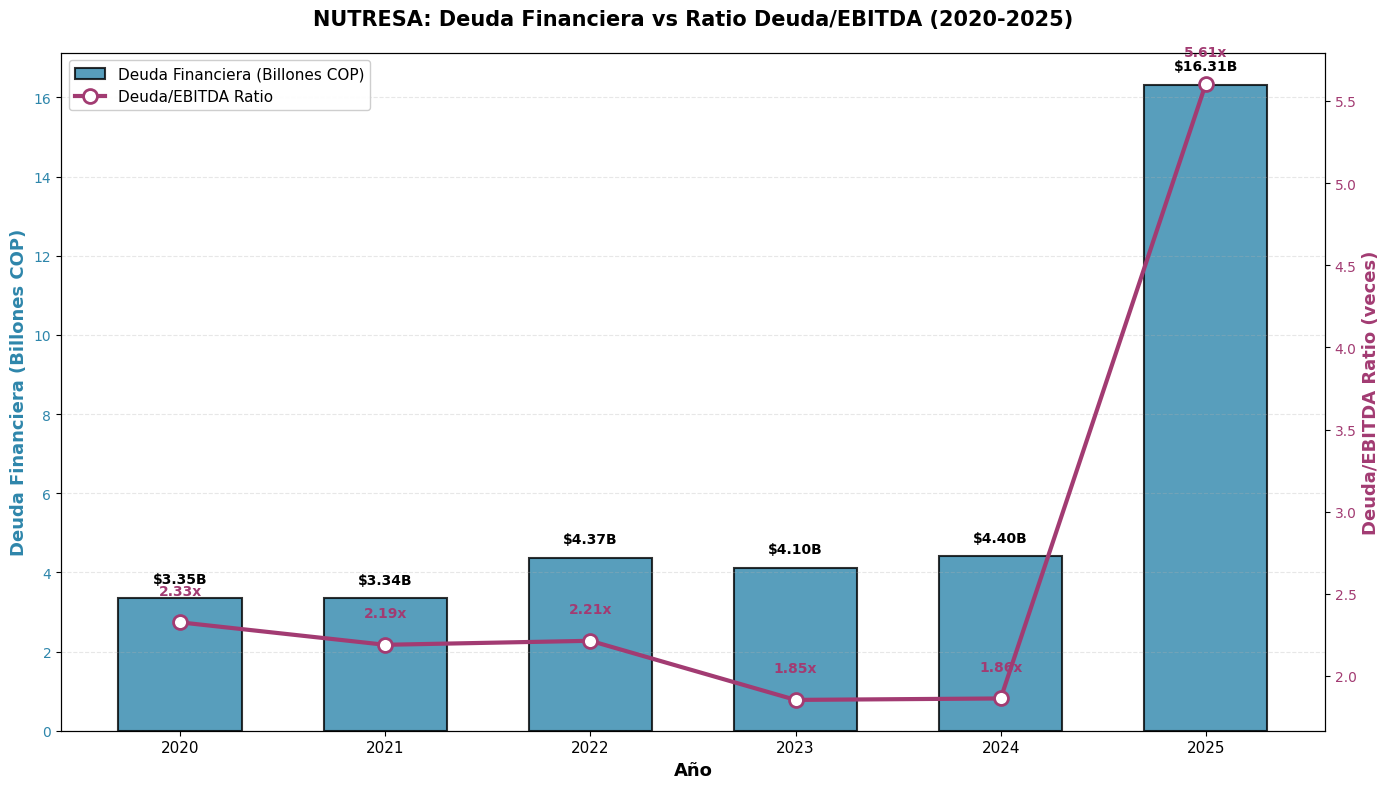

In [14]:

# PASO 5b: Visualización Deuda/EBITDA (Gráfico Dual Axis)

fig, ax1 = plt.subplots(figsize=(14, 8))

years = df_debt_ebitda['Año'].astype(str).values
x_pos = np.arange(len(years))
width = 0.6

# Eje izquierdo: Barras de Deuda en Billones COP
color_bars = '#2E86AB'  # Azul
bars = ax1.bar(x_pos, df_debt_ebitda['Deuda_Billions'], width, 
               label='Deuda Financiera (Billones COP)', 
               color=color_bars, alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Deuda Financiera (Billones COP)', fontsize=13, fontweight='bold', color=color_bars)
ax1.set_title('NUTRESA: Deuda Financiera vs Ratio Deuda/EBITDA (2020-2025)', 
              fontsize=15, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(years, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_bars, labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Datos en las barras
for i, (bar, val) in enumerate(zip(bars, df_debt_ebitda['Deuda_Billions'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'${val:.2f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Eje derecho: Línea del Ratio Deuda/EBITDA
ax2 = ax1.twinx()
color_line = '#A23B72'  # Magenta
line = ax2.plot(x_pos, df_debt_ebitda['Deuda_EBITDA_Ratio'], 
                color=color_line, marker='o', linewidth=3, markersize=10, 
                label='Deuda/EBITDA Ratio', markerfacecolor='white', 
                markeredgewidth=2, markeredgecolor=color_line)

ax2.set_ylabel('Deuda/EBITDA Ratio (veces)', fontsize=13, fontweight='bold', color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line, labelsize=10)

# Datos en la línea
for i, (x, y) in enumerate(zip(x_pos, df_debt_ebitda['Deuda_EBITDA_Ratio'])):
    ax2.text(x, y + 0.15, f'{y:.2f}x', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color=color_line)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11, framealpha=0.95)

# Formato final
fig.tight_layout()
plt.show()


## EBITDA/intereses

In [15]:
# ========================================================================================
# NUEVA MÉTRICA: EBITDA/INTERESES (INTEREST COVERAGE RATIO)
# ========================================================================================

# PASO 1: Extracción de ifrs:InterestExpense (Contexto _ctx0)

print("EBITDA/Intereses - PASO 1: Extrayendo ifrs:InterestExpense (ctx0)")
print("=" * 100)

interest_expense_data = {}

years_to_extract = {
    "2020": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01"],
    "2021": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01"],
    "2022": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01"],
    "2023": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01"],
    "2024": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01"],
    "2025": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01"],
}

for year, (xbrl_filename, period_end_str) in years_to_extract.items():
    xbrl_file = os.path.join(XBRL_PATH_NUTRESA, xbrl_filename)
    period_end = pd.to_datetime(period_end_str)
    
    xbrl = Cntlr.Cntlr().modelManager.load(xbrl_file)
    
    # Buscar ifrs:InterestExpense con contexto _ctx0
    encontrado = False
    for fact in xbrl.facts:
        concepto = str(fact.concept.qname)
        context_id = fact.context.id
        
        if concepto == 'ifrs:InterestExpense' and context_id == '_ctx0':
            try:
                valor = float(fact.value) if fact.value else 0
            except:
                valor = 0
            
            interest_expense_data[year] = valor
            print(f"✓ {year}: ifrs:InterestExpense = ${valor:>20,.0f} ({context_id})")
            encontrado = True
            break
    
    if not encontrado:
        print(f"⚠ {year}: No se encontró en contexto _ctx0")
        interest_expense_data[year] = 0

print("\n" + "=" * 100)
print(f"Resultado: Se extrajeron {len([v for v in interest_expense_data.values() if v != 0])} años con valores")
print("=" * 100)
for year, valor in sorted(interest_expense_data.items()):
    print(f"  {year}: ${valor:>20,.0f}")

EBITDA/Intereses - PASO 1: Extrayendo ifrs:InterestExpense (ctx0)
✓ 2020: ifrs:InterestExpense = $         187,491,798 (_ctx0)
✓ 2021: ifrs:InterestExpense = $         138,954,121 (_ctx0)
✓ 2022: ifrs:InterestExpense = $         321,986,368 (_ctx0)
✓ 2023: ifrs:InterestExpense = $         620,311,594 (_ctx0)
✓ 2024: ifrs:InterestExpense = $         513,788,760 (_ctx0)
✓ 2025: ifrs:InterestExpense = $       1,256,755,590 (_ctx0)

Resultado: Se extrajeron 6 años con valores
  2020: $         187,491,798
  2021: $         138,954,121
  2022: $         321,986,368
  2023: $         620,311,594
  2024: $         513,788,760
  2025: $       1,256,755,590


In [16]:

# PASO 2: Cálculo de EBITDA/Intereses Ratio

print("EBITDA/Intereses - PASO 2: Calculando Interest Coverage Ratio")
print("=" * 100)

ebitda_interest_ratio = {}

for year in sorted(interest_expense_data.keys()):
    ebitda_value = ebitda_data.get(year, 0)
    interest_value = interest_expense_data.get(year, 0)
    
    if interest_value != 0:
        ratio = ebitda_value / interest_value
    else:
        ratio = 0
    
    ebitda_interest_ratio[year] = ratio
    
    print(f"{year}:")
    print(f"  EBITDA:          ${ebitda_value:>20,.0f}")
    print(f"  Interest Expense: ${interest_value:>20,.0f}")
    print(f"  EBITDA/Intereses: {ratio:>25.2f}x")
    print()

print("=" * 100)
print("Resumen de EBITDA/Intereses Ratio:")
print("=" * 100)
for year in sorted(ebitda_interest_ratio.keys()):
    ratio = ebitda_interest_ratio[year]
    print(f"  {year}: {ratio:.2f}x")

# Crear DataFrame para visualización
years_list = sorted(interest_expense_data.keys())
interest_billions = [interest_expense_data[year] / 1e9 for year in years_list]
ratios = [ebitda_interest_ratio[year] for year in years_list]

df_ebitda_interest = pd.DataFrame({
    'Año': years_list,
    'Intereses_Billions': interest_billions,
    'EBITDA_Intereses_Ratio': ratios
})

print("\n" + "=" * 100)
print("DataFrame preparado para visualización:")
print("=" * 100)
print(df_ebitda_interest)


EBITDA/Intereses - PASO 2: Calculando Interest Coverage Ratio
2020:
  EBITDA:          $       1,440,972,295
  Interest Expense: $         187,491,798
  EBITDA/Intereses:                      7.69x

2021:
  EBITDA:          $       1,525,951,677
  Interest Expense: $         138,954,121
  EBITDA/Intereses:                     10.98x

2022:
  EBITDA:          $       1,974,189,696
  Interest Expense: $         321,986,368
  EBITDA/Intereses:                      6.13x

2023:
  EBITDA:          $       2,213,182,591
  Interest Expense: $         620,311,594
  EBITDA/Intereses:                      3.57x

2024:
  EBITDA:          $       2,363,835,415
  Interest Expense: $         513,788,760
  EBITDA/Intereses:                      4.60x

2025:
  EBITDA:          $       2,909,838,872
  Interest Expense: $       1,256,755,590
  EBITDA/Intereses:                      2.32x

Resumen de EBITDA/Intereses Ratio:
  2020: 7.69x
  2021: 10.98x
  2022: 6.13x
  2023: 3.57x
  2024: 4.60x
  2025: 2.

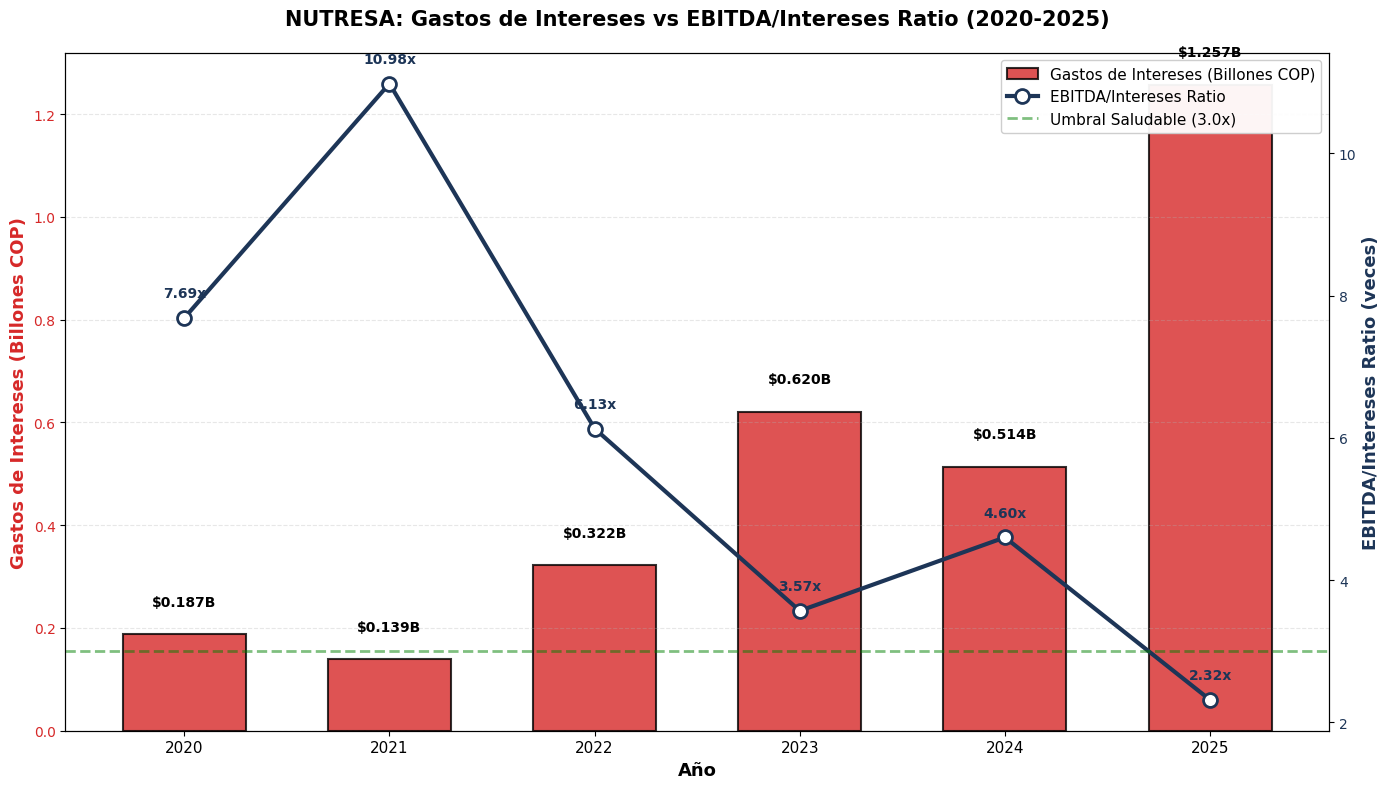

In [17]:

# PASO 3: Visualización EBITDA/Intereses (Gráfico Dual Axis)

fig, ax1 = plt.subplots(figsize=(14, 8))

years = df_ebitda_interest['Año'].astype(str).values
x_pos = np.arange(len(years))
width = 0.6

# Eje izquierdo: Barras de Gastos de Intereses en Billones COP
color_bars = '#D62828'  # Rojo
bars = ax1.bar(x_pos, df_ebitda_interest['Intereses_Billions'], width, 
               label='Gastos de Intereses (Billones COP)', 
               color=color_bars, alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Gastos de Intereses (Billones COP)', fontsize=13, fontweight='bold', color=color_bars)
ax1.set_title('NUTRESA: Gastos de Intereses vs EBITDA/Intereses Ratio (2020-2025)', 
              fontsize=15, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(years, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_bars, labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Datos en las barras
for i, (bar, val) in enumerate(zip(bars, df_ebitda_interest['Intereses_Billions'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'${val:.3f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Eje derecho: Línea del Ratio EBITDA/Intereses
ax2 = ax1.twinx()
color_line = '#1D3557'  # Azul marino
line = ax2.plot(x_pos, df_ebitda_interest['EBITDA_Intereses_Ratio'], 
                color=color_line, marker='o', linewidth=3, markersize=10, 
                label='EBITDA/Intereses Ratio', markerfacecolor='white', 
                markeredgewidth=2, markeredgecolor=color_line)

ax2.set_ylabel('EBITDA/Intereses Ratio (veces)', fontsize=13, fontweight='bold', color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line, labelsize=10)
ax2.axhline(y=3.0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Umbral Saludable (3.0x)')

# Datos en la línea
for i, (x, y) in enumerate(zip(x_pos, df_ebitda_interest['EBITDA_Intereses_Ratio'])):
    ax2.text(x, y + 0.25, f'{y:.2f}x', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color=color_line)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11, framealpha=0.95)

# Formato final
fig.tight_layout()
plt.show()



## DEBT-TO-EQUITY RATIO

In [20]:
data_summary_df_nutresa

,Equity,Liabilities,CurrentLiabilities,SharesOutstanding
Date,,,,
2021-01-01,8.257142e+09,7.280741e+09,2.440661e+09,460123458.0
2022-01-01,9.042112e+09,7.914371e+09,2.628037e+09,457755869.0
2023-01-01,1.080470e+10,9.952691e+09,3.808715e+09,457755869.0
2024-01-01,6.444251e+09,9.244579e+09,3.703272e+09,457755869.0
2024-04-01,6.517739e+09,8.859939e+09,3.319459e+09,0.0
2024-07-01,7.031867e+09,9.294203e+09,3.391174e+09,0.0
2024-10-01,6.849715e+09,9.938925e+09,3.647421e+09,0.0
2025-01-01,7.118852e+09,9.823609e+09,3.701407e+09,457755869.0
2025-04-01,7.209828e+09,1.835279e+10,1.164962e+10,0.0


In [23]:

# ========================================================================================
# NUEVA MÉTRICA: LIABILITIES/EQUITY (DEBT-TO-EQUITY RATIO)
# ========================================================================================

# PASO 1: Extracción de Liabilities y Equity desde data_summary_df_nutresa

print("\nLiabilities/Equity - PASO 1: Extrayendo datos de Liabilities y Equity")
print("=" * 100)

# Filtrar solo datos de cierre de año (Diciembre - endDatetime en enero)
data_year_end = data_summary_df_nutresa[data_summary_df_nutresa.index.to_series().dt.month == 1].copy()

# Extraer años
data_year_end['Year'] = data_year_end.index.to_series().dt.year - 1  # Restar 1 porque enero es cierre de año anterior

liabilities_equity_data = {}

for idx, row in data_year_end.iterrows():
    year = str(int(row['Year']))
    liabilities = row['Liabilities']
    equity = row['Equity']
    
    liabilities_equity_data[year] = {
        'Liabilities': liabilities,
        'Equity': equity
    }
    
    print(f"✓ {year}: Liabilities = ${liabilities:>15,.0f}, Equity = ${equity:>15,.0f}")

print("\n" + "=" * 100)
print(f"Resultado: Se extrajeron {len(liabilities_equity_data)} años")
print("=" * 100)


Liabilities/Equity - PASO 1: Extrayendo datos de Liabilities y Equity
✓ 2020: Liabilities = $  7,280,740,775, Equity = $  8,257,141,744
✓ 2021: Liabilities = $  7,914,370,766, Equity = $  9,042,111,934
✓ 2022: Liabilities = $  9,952,691,427, Equity = $ 10,804,696,453
✓ 2023: Liabilities = $  9,244,578,686, Equity = $  6,444,251,335
✓ 2024: Liabilities = $  9,823,609,331, Equity = $  7,118,852,385
✓ 2025: Liabilities = $ 22,002,614,449, Equity = $  5,416,711,524

Resultado: Se extrajeron 6 años


In [24]:

# PASO 2: Cálculo de Liabilities/Equity Ratio

print("Liabilities/Equity - PASO 2: Calculando Debt-to-Equity Ratio")
print("=" * 100)

liabilities_equity_ratio = {}

for year in sorted(liabilities_equity_data.keys()):
    liabilities = liabilities_equity_data[year]['Liabilities']
    equity = liabilities_equity_data[year]['Equity']
    
    if equity != 0:
        ratio = liabilities / equity
    else:
        ratio = 0
    
    liabilities_equity_ratio[year] = ratio
    
    print(f"{year}:")
    print(f"  Total Liabilities: ${liabilities:>20,.0f}")
    print(f"  Total Equity:      ${equity:>20,.0f}")
    print(f"  Liabilities/Equity: {ratio:>25.2f}x")
    print()

print("=" * 100)
print("Resumen de Liabilities/Equity Ratio:")
print("=" * 100)
for year in sorted(liabilities_equity_ratio.keys()):
    ratio = liabilities_equity_ratio[year]
    print(f"  {year}: {ratio:.2f}x")

# Crear DataFrame para visualización
years_list = sorted(liabilities_equity_data.keys())
liabilities_billions = [liabilities_equity_data[year]['Liabilities'] / 1e9 for year in years_list]
equity_billions = [liabilities_equity_data[year]['Equity'] / 1e9 for year in years_list]
ratios = [liabilities_equity_ratio[year] for year in years_list]

df_liabilities_equity = pd.DataFrame({
    'Año': years_list,
    'Liabilities_Billions': liabilities_billions,
    'Equity_Billions': equity_billions,
    'Liabilities_Equity_Ratio': ratios
})

print("\n" + "=" * 100)
print("DataFrame preparado para visualización:")
print("=" * 100)
print(df_liabilities_equity)


Liabilities/Equity - PASO 2: Calculando Debt-to-Equity Ratio
2020:
  Total Liabilities: $       7,280,740,775
  Total Equity:      $       8,257,141,744
  Liabilities/Equity:                      0.88x

2021:
  Total Liabilities: $       7,914,370,766
  Total Equity:      $       9,042,111,934
  Liabilities/Equity:                      0.88x

2022:
  Total Liabilities: $       9,952,691,427
  Total Equity:      $      10,804,696,453
  Liabilities/Equity:                      0.92x

2023:
  Total Liabilities: $       9,244,578,686
  Total Equity:      $       6,444,251,335
  Liabilities/Equity:                      1.43x

2024:
  Total Liabilities: $       9,823,609,331
  Total Equity:      $       7,118,852,385
  Liabilities/Equity:                      1.38x

2025:
  Total Liabilities: $      22,002,614,449
  Total Equity:      $       5,416,711,524
  Liabilities/Equity:                      4.06x

Resumen de Liabilities/Equity Ratio:
  2020: 0.88x
  2021: 0.88x
  2022: 0.92x
  2023: 

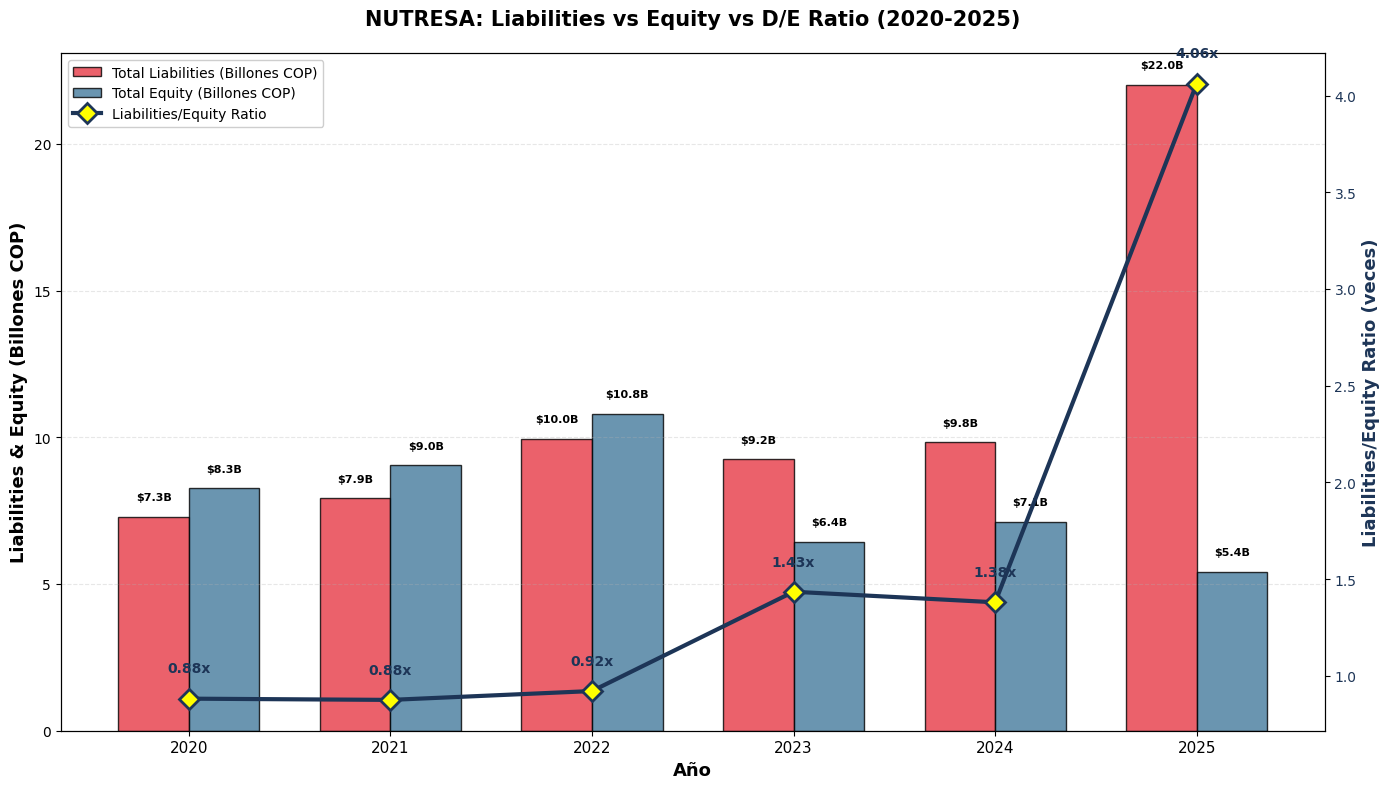

In [25]:

# PASO 3: Visualización Liabilities/Equity (Gráfico Barras Agrupadas + Línea)

fig, ax1 = plt.subplots(figsize=(14, 8))

years = df_liabilities_equity['Año'].astype(str).values
x_pos = np.arange(len(years))
width = 0.35

# Eje izquierdo: Barras de Liabilities y Equity en Billones COP
color_liab = '#E63946'  # Rojo
color_equity = '#457B9D'  # Azul

bars1 = ax1.bar(x_pos - width/2, df_liabilities_equity['Liabilities_Billions'], width, 
                label='Total Liabilities (Billones COP)', 
                color=color_liab, alpha=0.8, edgecolor='black', linewidth=1)

bars2 = ax1.bar(x_pos + width/2, df_liabilities_equity['Equity_Billions'], width, 
                label='Total Equity (Billones COP)', 
                color=color_equity, alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_xlabel('Año', fontsize=13, fontweight='bold')
ax1.set_ylabel('Liabilities & Equity (Billones COP)', fontsize=13, fontweight='bold')
ax1.set_title('NUTRESA: Liabilities vs Equity vs D/E Ratio (2020-2025)', 
              fontsize=15, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(years, fontsize=11)
ax1.tick_params(axis='y', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Datos en las barras de Liabilities
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
             f'${height:.1f}B', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Datos en las barras de Equity
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
             f'${height:.1f}B', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Eje derecho: Línea del Ratio Liabilities/Equity
ax2 = ax1.twinx()
color_line = '#1D3557'  # Azul marino
line = ax2.plot(x_pos, df_liabilities_equity['Liabilities_Equity_Ratio'], 
                color=color_line, marker='D', linewidth=3, markersize=10, 
                label='Liabilities/Equity Ratio', markerfacecolor='yellow', 
                markeredgewidth=2, markeredgecolor=color_line)

ax2.set_ylabel('Liabilities/Equity Ratio (veces)', fontsize=13, fontweight='bold', color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line, labelsize=10)


# Datos en la línea
for i, (x, y) in enumerate(zip(x_pos, df_liabilities_equity['Liabilities_Equity_Ratio'])):
    ax2.text(x, y + 0.12, f'{y:.2f}x', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color=color_line)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, framealpha=0.95)

# Formato final
fig.tight_layout()
plt.show()



## Metricas de Rentabilidad y CashFlow

In [ ]:

# PASO 1: Extraer Revenue, Gross Profit, Net Profit y Cash Flow from Operations

print("\nPerformance Operacional - PASO 1: Extrayendo métricas operacionales")
print("=" * 100)

operational_metrics = {}

years_to_extract = {
    "2020": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01"],
    "2021": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01"],
    "2022": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01"],
    "2023": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01"],
    "2024": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01"],
    "2025": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01"],
}

for year, (xbrl_filename, period_end_str) in years_to_extract.items():
    xbrl_file = os.path.join(XBRL_PATH_NUTRESA, xbrl_filename)
    period_end = pd.to_datetime(period_end_str)
    period_start = pd.to_datetime(f"{int(year)}-01-01")
    
    xbrl = Cntlr.Cntlr().modelManager.load(xbrl_file)
    
    metrics = {
        'Revenue': 0,
        'GrossProfit': 0,
        'NetProfit': 0,
        'CashFlowOperations': 0
    }
    
    # Buscar todos los conceptos
    for fact in xbrl.facts:
        concepto = str(fact.concept.qname)
        context_id = fact.context.id
        
        try:
            valor = float(fact.value) if fact.value else 0
        except:
            valor = 0
        
        # Revenue (período completo)
        if concepto == 'ifrs:Revenue' and context_id in ['_ctx4', '_ctx2794']:
            fecha_inicio = fact.context.startDatetime if hasattr(fact.context, 'startDatetime') else None
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_inicio == period_start and fecha_fin == period_end:
                if valor > metrics['Revenue']:  # Tomar mayor valor
                    metrics['Revenue'] = valor
        
        # Gross Profit
        elif concepto == 'ifrs:GrossProfit' and context_id == '_ctx4':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['GrossProfit'] = valor
        
        # Net Profit (usar ProfitLossFromContinuingOperations)
        elif concepto == 'ifrs:ProfitLossFromContinuingOperations' and context_id == '_ctx4':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['NetProfit'] = valor
        
        # Cash Flow from Operating Activities
        elif concepto == 'ifrs:CashFlowsFromUsedInOperatingActivities' and context_id == '_ctx4':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['CashFlowOperations'] = valor

                
    
    operational_metrics[year] = metrics

# Calcular márgenes
print("\nResumen de Métricas Operacionales:")
print("=" * 100)
for year, metrics in sorted(operational_metrics.items()):
    revenue = metrics['Revenue']
    gross_profit = metrics['GrossProfit']
    net_profit = metrics['NetProfit']
    cash_flow = metrics['CashFlowOperations']
    
    gross_margin = (gross_profit / revenue * 100) if revenue > 0 else 0
    net_margin = (net_profit / revenue * 100) if revenue > 0 else 0
    
    operational_metrics[year]['GrossMargin'] = gross_margin
    operational_metrics[year]['NetMargin'] = net_margin
    
    print(f"\n{year}:")
    print(f"  Revenue:               ${revenue:>18,.0f}")
    print(f"  Gross Profit:          ${gross_profit:>18,.0f}  ({gross_margin:>6.2f}%)")
    print(f"  Net Profit:            ${net_profit:>18,.0f}  ({net_margin:>6.2f}%)")
    print(f"  Operating Cash Flow:   ${cash_flow:>18,.0f}")



Performance Operacional - PASO 1: Extrayendo métricas operacionales

Resumen de Métricas Operacionales:

2020:
  Revenue:               $    11,226,010,444
  Gross Profit:          $     4,662,413,062  ( 41.53%)
  Net Profit:            $       584,397,361  (  5.21%)
  Operating Cash Flow:   $       583,843,991

2021:
  Revenue:               $    12,863,141,712
  Gross Profit:          $     5,127,387,165  ( 39.86%)
  Net Profit:            $       724,461,057  (  5.63%)
  Operating Cash Flow:   $       693,254,186

2022:
  Revenue:               $    17,206,249,657
  Gross Profit:          $     6,238,227,591  ( 36.26%)
  Net Profit:            $       903,801,288  (  5.25%)
  Operating Cash Flow:   $       903,766,794

2023:
  Revenue:               $    19,062,242,283
  Gross Profit:          $     7,397,970,792  ( 38.81%)
  Net Profit:            $       739,614,817  (  3.88%)
  Operating Cash Flow:   $       739,614,817

2024:
  Revenue:               $    18,743,160,044
  Gross


Performance Operacional - PASO 2: Preparando visualizaciones

DataFrame de Performance Operacional:
    Año  Revenue_Billions  GrossProfit_Billions  NetProfit_Billions  \
0  2020         11.226010              4.662413            0.584397   
1  2021         12.863142              5.127387            0.724461   
2  2022         17.206250              6.238228            0.903801   
3  2023         19.062242              7.397971            0.739615   
4  2024         18.743160              7.628484            0.765354   
5  2025         20.751229              8.121175            1.357692   

   CashFlow_Billions  GrossMargin_%  NetMargin_%  
0           0.583844      41.532235     5.205744  
1           0.693254      39.861080     5.632069  
2           0.903767      36.255592     5.252750  
3           0.739615      38.809552     3.879999  
4           0.765354      40.700096     4.083380  
5           1.245336      39.135877     6.542704  


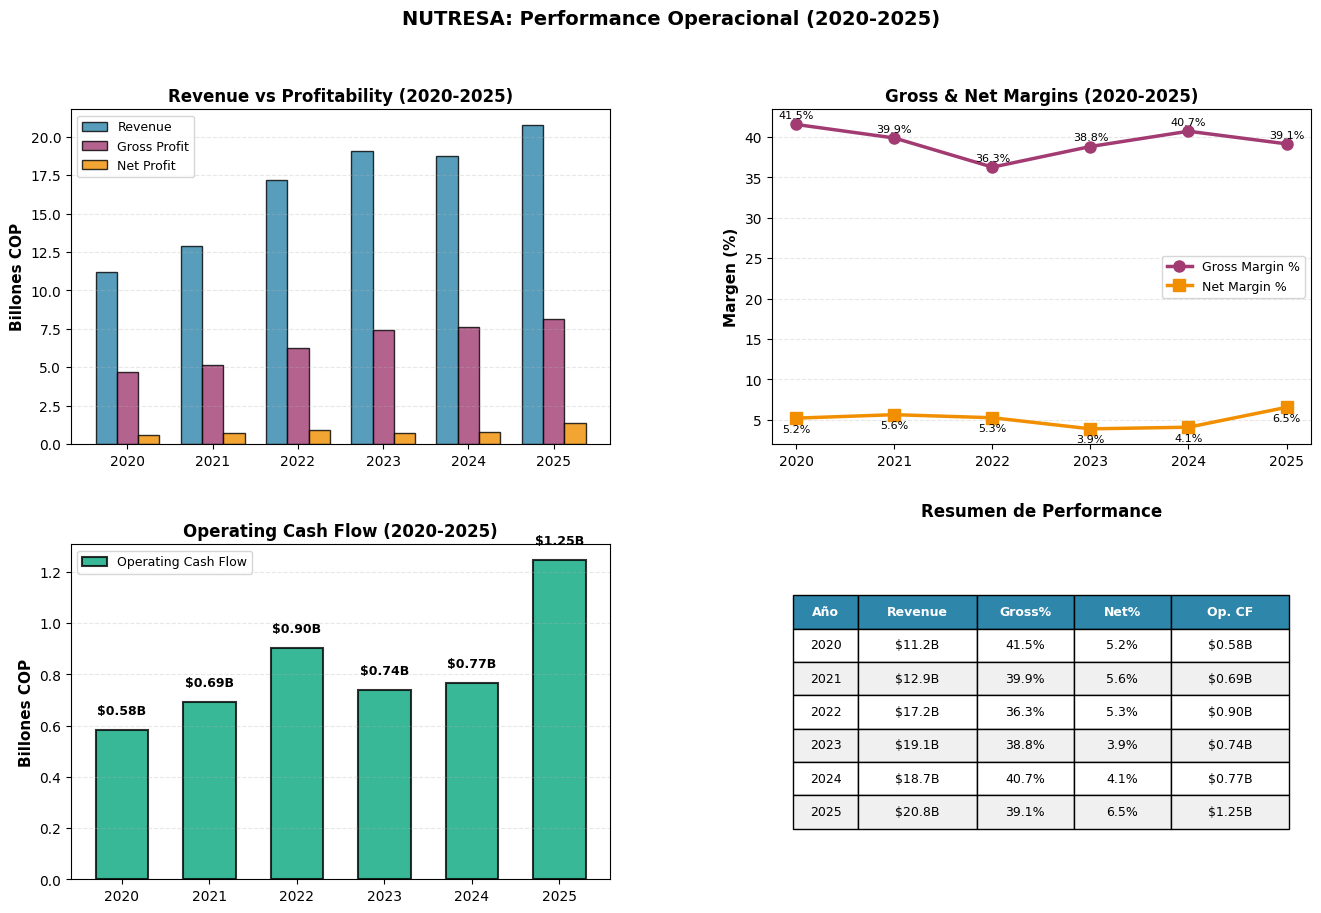


Visualizaciones generadas exitosamente


In [ ]:

# PASO 2: Crear DataFrame y visualizaciones

print("\nPerformance Operacional - PASO 2: Preparando visualizaciones")
print("=" * 100)

# Crear DataFrame
years_list = sorted(operational_metrics.keys())
df_operational = pd.DataFrame([
    {
        'Año': year,
        'Revenue_Billions': operational_metrics[year]['Revenue'] / 1e9,
        'GrossProfit_Billions': operational_metrics[year]['GrossProfit'] / 1e9,
        'NetProfit_Billions': operational_metrics[year]['NetProfit'] / 1e9,
        'CashFlow_Billions': operational_metrics[year]['CashFlowOperations'] / 1e9,
        'GrossMargin_%': operational_metrics[year]['GrossMargin'],
        'NetMargin_%': operational_metrics[year]['NetMargin']
    }
    for year in years_list
])

print("\nDataFrame de Performance Operacional:")
print(df_operational)

# Crear figura con subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

years = df_operational['Año'].astype(str).values
x_pos = np.arange(len(years))

# ========== Gráfico 1: Revenue vs Profitability ==========
ax1 = fig.add_subplot(gs[0, 0])
width = 0.25

bars1 = ax1.bar(x_pos - width, df_operational['Revenue_Billions'], width, 
                label='Revenue', color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax1.bar(x_pos, df_operational['GrossProfit_Billions'], width, 
                label='Gross Profit', color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)
bars3 = ax1.bar(x_pos + width, df_operational['NetProfit_Billions'], width, 
                label='Net Profit', color='#F18F01', alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_ylabel('Billones COP', fontsize=11, fontweight='bold')
ax1.set_title('Revenue vs Profitability (2020-2025)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(years)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ========== Gráfico 2: Márgenes Bruto y Neto ==========
ax2 = fig.add_subplot(gs[0, 1])

line1 = ax2.plot(x_pos, df_operational['GrossMargin_%'], color='#A23B72', 
                 marker='o', linewidth=2.5, markersize=8, label='Gross Margin %')
line2 = ax2.plot(x_pos, df_operational['NetMargin_%'], color='#F18F01', 
                 marker='s', linewidth=2.5, markersize=8, label='Net Margin %')

ax2.set_ylabel('Margen (%)', fontsize=11, fontweight='bold')
ax2.set_title('Gross & Net Margins (2020-2025)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(years)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores en los puntos
for i, (x, y) in enumerate(zip(x_pos, df_operational['GrossMargin_%'])):
    ax2.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)
for i, (x, y) in enumerate(zip(x_pos, df_operational['NetMargin_%'])):
    ax2.text(x, y - 0.7, f'{y:.1f}%', ha='center', va='top', fontsize=8)

# ========== Gráfico 3: Operating Cash Flow ==========
ax3 = fig.add_subplot(gs[1, 0])

bars = ax3.bar(x_pos, df_operational['CashFlow_Billions'], width=0.6, 
               label='Operating Cash Flow', color='#06A77D', alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.set_ylabel('Billones COP', fontsize=11, fontweight='bold')
ax3.set_title('Operating Cash Flow (2020-2025)', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(years)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Datos en barras
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 0.05, 
             f'${height:.2f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ========== Gráfico 4: Tabla de Resumen ==========
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Crear tabla resumen
table_data = []
for _, row in df_operational.iterrows():
    table_data.append([
        int(row['Año']),
        f"${row['Revenue_Billions']:.1f}B",
        f"{row['GrossMargin_%']:.1f}%",
        f"{row['NetMargin_%']:.1f}%",
        f"${row['CashFlow_Billions']:.2f}B"
    ])

table = ax4.table(cellText=table_data,
                  colLabels=['Año', 'Revenue', 'Gross%', 'Net%', 'Op. CF'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.12, 0.22, 0.18, 0.18, 0.22])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Formato de header
for i in range(5):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colores alternados para filas
for i in range(1, len(table_data) + 1):
    color = '#F0F0F0' if i % 2 == 0 else 'white'
    for j in range(5):
        table[(i, j)].set_facecolor(color)

ax4.set_title('Resumen de Performance', fontsize=12, fontweight='bold', pad=20)

# Título general
fig.suptitle('NUTRESA: Performance Operacional (2020-2025)', 
             fontsize=14, fontweight='bold', y=0.98)

plt.show()

## Ratios de Actividad

In [28]:
print("\nPerformance Operacional - PASO 1: Extrayendo métricas operacionales")
print("=" * 100)

activity_metrics = {}

years_to_extract = {
    "2020": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01"],
    "2021": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01"],
    "2022": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01"],
    "2023": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01"],
    "2024": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01"],
    "2025": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01"],
}

for year, (xbrl_filename, period_end_str) in years_to_extract.items():
    xbrl_file = os.path.join(XBRL_PATH_NUTRESA, xbrl_filename)
    period_end = pd.to_datetime(period_end_str)
    period_start = pd.to_datetime(f"{int(year)}-01-01")
    
    xbrl = Cntlr.Cntlr().modelManager.load(xbrl_file)
    
    metrics = {
        'Revenue': 0,
        'CostOfSales': 0,

        'CxC': 0,
        'Inventarios': 0,
        'CxP': 0,

        'RotacionCxC': 0,
        'RotacionInventarios': 0,
        'RotacionCxP': 0
    }
    
    # Buscar todos los conceptos
    for fact in xbrl.facts:
        concepto = str(fact.concept.qname)
        context_id = fact.context.id
        
        try:
            valor = float(fact.value) if fact.value else 0
        except:
            valor = 0
        
        # Revenue (período completo)
        if concepto == 'ifrs:Revenue' and context_id in ['_ctx4', '_ctx2794']:
            fecha_inicio = fact.context.startDatetime if hasattr(fact.context, 'startDatetime') else None
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_inicio == period_start and fecha_fin == period_end:
                if valor > metrics['Revenue']:  # Tomar mayor valor
                    metrics['Revenue'] = valor
        
        # Cost of Sales
        elif concepto == 'ifrs:CostOfSales' and context_id == '_ctx4':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['CostOfSales'] = valor
        
        # CxC
        elif concepto == 'ifrs:TradeAndOtherCurrentReceivables' and context_id == '_ctx1':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['CxC'] = valor
        
        # CxP
        elif concepto == 'ifrs:TradeAndOtherCurrentPayablesToTradeSuppliers' and context_id == '_ctx1':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['CxP'] = valor

        # Inventarios
        elif concepto == 'ifrs:Inventories' and context_id == '_ctx1':
            fecha_fin = fact.context.endDatetime if hasattr(fact.context, 'endDatetime') else None
            if fecha_fin == period_end:
                metrics['Inventarios'] = valor


    activity_metrics[year] = metrics

# Calcular ratios de rotación
for year, metrics in sorted(activity_metrics.items()):
    revenue = metrics['Revenue']
    cost_of_sales = metrics['CostOfSales']

    cxc = metrics['CxC']
    cxp = metrics['CxP']
    inventarios = metrics['Inventarios']

    r_cxc = (cxc / revenue * 365) if revenue > 0 else 0
    r_inventarios = (inventarios / cost_of_sales * 365) if cost_of_sales > 0 else 0
    r_cxp = (cxp / cost_of_sales * 365) if cost_of_sales > 0 else 0

    activity_metrics[year]['RotacionCxC'] = r_cxc
    activity_metrics[year]['RotacionInventarios'] = r_inventarios
    activity_metrics[year]['RotacionCxP'] = r_cxp
    


Performance Operacional - PASO 1: Extrayendo métricas operacionales



Performance Actividad - PASO 2: Preparando visualizaciones

DataFrame de Performance Operacional:
    Año  RotaciónCxC  RotaciónInventarios  RotaciónCxP
0  2020    38.747022            77.909378    40.818767
1  2021    39.234176            83.569136    52.713065
2  2022    39.387556           101.536117    48.281936
3  2023    32.624560            70.816086    32.509834
4  2024    41.256331            81.510371    41.419023
5  2025    37.081393            74.968939    67.465946


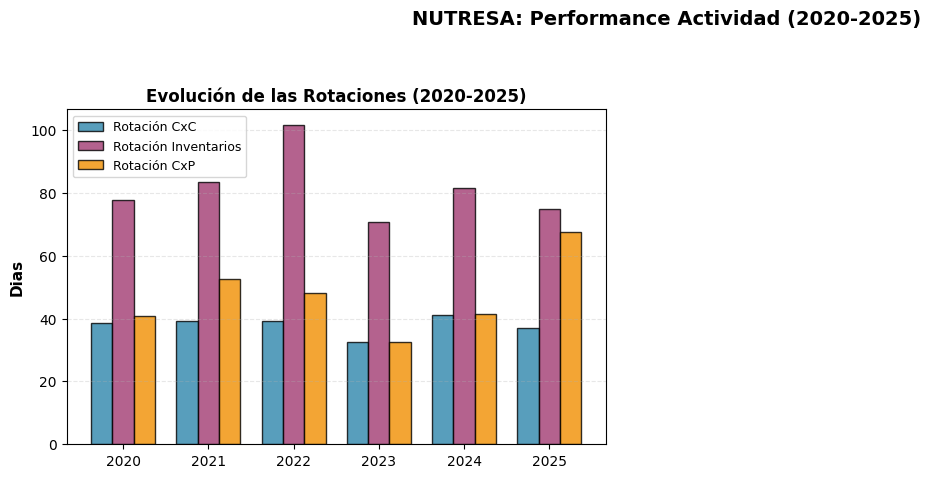

In [34]:
# PASO 2: Crear DataFrame y visualizaciones

print("\nPerformance Actividad - PASO 2: Preparando visualizaciones")
print("=" * 100)

# Crear DataFrame
years_list = sorted(activity_metrics.keys())
df_activity = pd.DataFrame([
    {
        'Año': year,
        'RotaciónCxC': activity_metrics[year]['RotacionCxC'],
        'RotaciónInventarios': activity_metrics[year]['RotacionInventarios'],
        'RotaciónCxP': activity_metrics[year]['RotacionCxP']
    }
    for year in years_list
])

print("\nDataFrame de Performance Operacional:")
print(df_activity)

# Crear figura con subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

years = df_activity['Año'].astype(str).values
x_pos = np.arange(len(years))

# ========== Gráfico 1: Revenue vs Profitability ==========
ax1 = fig.add_subplot(gs[0, 0])
width = 0.25

bars1 = ax1.bar(x_pos - width, df_activity['RotaciónCxC'], width, 
                label='Rotación CxC', color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax1.bar(x_pos, df_activity['RotaciónInventarios'], width, 
                label='Rotación Inventarios', color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)
bars3 = ax1.bar(x_pos + width, df_activity['RotaciónCxP'], width, 
                label='Rotación CxP', color='#F18F01', alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_ylabel('Dias', fontsize=11, fontweight='bold')
ax1.set_title('Evolución de las Rotaciones (2020-2025)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(years)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')


# Título general
fig.suptitle('NUTRESA: Performance Actividad (2020-2025)', 
             fontsize=14, fontweight='bold', y=0.98)

plt.show()